## Model Analysis

* Results used in this notebook are derived from the baseline GRU model training.
* The code for this can be found in src/notebooks/test_eda1.py and src/notebooks/test_eda2.py

#### Imports and project root setup

In [38]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [39]:
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

#### Load the cached sequences

In [40]:
landmark_dir = PROJECT_ROOT / "data" / "processed" / "landmarks"

with open(landmark_dir / "train_sequences.pkl", "rb") as file:
    train_sequences = pickle.load(file)

with open(landmark_dir / "validation_sequences.pkl", "rb") as file:
    validation_sequences = pickle.load(file)

print("Training sequences:", len(train_sequences))
print("Validation sequences:", len(validation_sequences))

Training sequences: 2484
Validation sequences: 633


#### Loading the class names

In [41]:
from src.data.dataset import get_dataset_paths

paths = get_dataset_paths()

class_details = pd.read_csv(
    paths.class_details,
    sep="\t",
    skipinitialspace=True,
)

class_names = class_details["Label"].tolist()

print(class_names)

['D0X', 'B0A', 'B0B', 'G01', 'G02', 'G03', 'G04', 'G05', 'G06', 'G07', 'G08', 'G09', 'G10', 'G11']


#### 1. Create the Baseline results table

In [42]:
baseline_results = pd.DataFrame({
    "strategy": [
        "fixed_192",
        "fixed_256",
        "hybrid",
    ],
    "best_val_accuracy": [
        0.7472,
        0.7441,
        0.7520,
    ],
    "training_time_min": [
        29.20,
        92.81,
        14.97,
    ],
})

baseline_results

,strategy,best_val_accuracy,training_time_min
0,fixed_192,0.7472,29.20
1,fixed_256,0.7441,92.81
2,hybrid,0.7520,14.97


#### 1.1 Plot the comparison of strategies

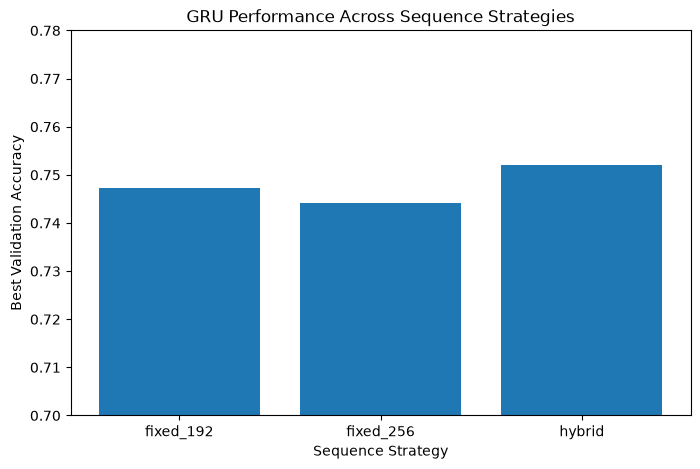

In [43]:
plt.figure(figsize=(8, 5))

plt.bar(
    baseline_results["strategy"],
    baseline_results["best_val_accuracy"],
)

plt.ylabel("Best Validation Accuracy")
plt.xlabel("Sequence Strategy")
plt.title("GRU Performance Across Sequence Strategies")
plt.ylim(0.70, 0.78)

plt.show()

#### 2. Class-wise performance

In [44]:
gesture_class_names = class_names[1:]

print(gesture_class_names)

['B0A', 'B0B', 'G01', 'G02', 'G03', 'G04', 'G05', 'G06', 'G07', 'G08', 'G09', 'G10', 'G11']


In [45]:
class_performance = pd.DataFrame({
    "class": gesture_class_names,
    "precision": [
        1.000, 0.925, 0.442, 0.143, 0.714, 0.893,
        0.900, 0.917, 0.541, 0.227, 0.375, 0.378, 0.714
    ],
    "recall": [
        0.941, 0.987, 0.633, 0.033, 0.333, 0.833,
        0.900, 0.733, 0.667, 0.167, 0.900, 0.567, 0.167
    ],
    "f1": [
        0.969, 0.955, 0.521, 0.054, 0.455, 0.862,
        0.900, 0.815, 0.597, 0.192, 0.529, 0.453, 0.270
    ],
})

class_performance

,class,precision,recall,f1
0,B0A,1.000,0.941,0.969
1,B0B,0.925,0.987,0.955
2,G01,0.442,0.633,0.521
3,G02,0.143,0.033,0.054
4,G03,0.714,0.333,0.455
5,G04,0.893,0.833,0.862
6,G05,0.900,0.900,0.900
7,G06,0.917,0.733,0.815
8,G07,0.541,0.667,0.597
9,G08,0.227,0.167,0.192


#### 2.1 Visualization

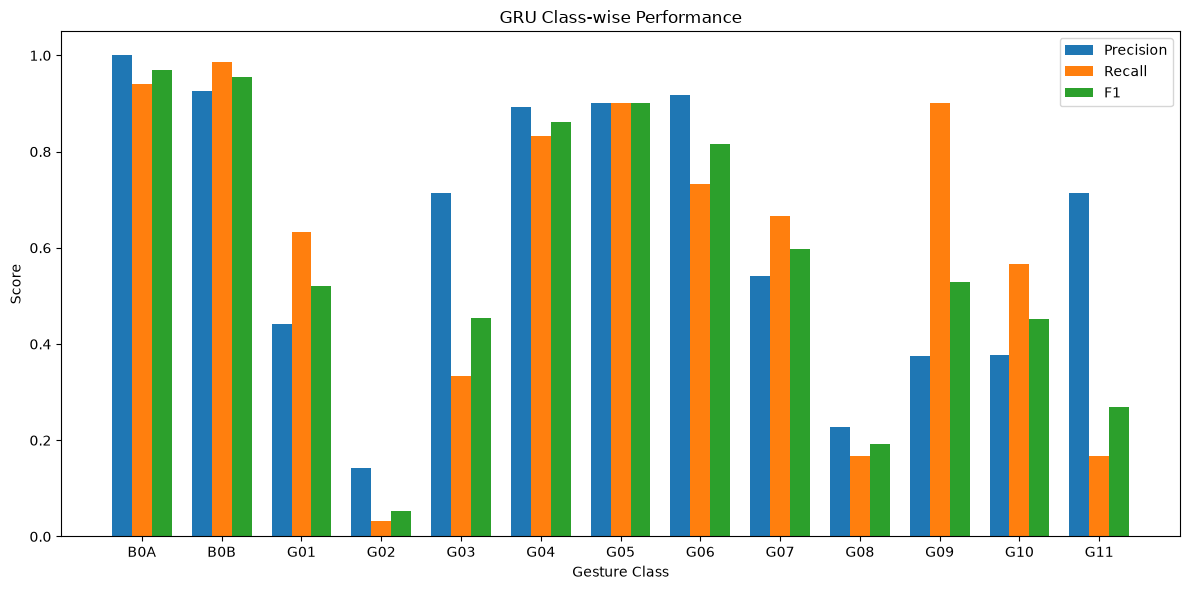

In [46]:
plt.figure(figsize=(12, 6))

x = np.arange(len(class_performance))
width = 0.25

plt.bar(
    x - width,
    class_performance["precision"],
    width,
    label="Precision",
)

plt.bar(
    x,
    class_performance["recall"],
    width,
    label="Recall",
)

plt.bar(
    x + width,
    class_performance["f1"],
    width,
    label="F1",
)

plt.xticks(x, class_performance["class"])
plt.ylabel("Score")
plt.xlabel("Gesture Class")
plt.title("GRU Class-wise Performance")
plt.ylim(0, 1.05)
plt.legend()

plt.tight_layout()
plt.show()

#### 2.3 Confusion Matrix

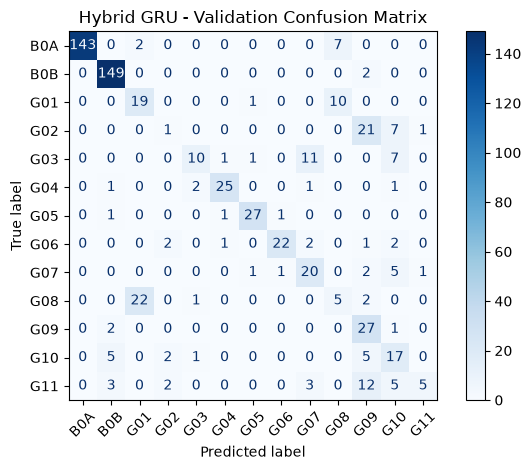

In [47]:
confusion_matrix_values = np.array([
    [143, 0, 2, 0, 0, 0, 0, 0, 0, 7, 0, 0, 0],
    [0, 149, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0],
    [0, 0, 19, 0, 0, 0, 1, 0, 0, 10, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 21, 7, 1],
    [0, 0, 0, 0, 10, 1, 1, 0, 11, 0, 0, 7, 0],
    [0, 1, 0, 0, 2, 25, 0, 0, 1, 0, 0, 1, 0],
    [0, 1, 0, 0, 0, 1, 27, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 2, 0, 1, 0, 22, 2, 0, 1, 2, 0],
    [0, 0, 0, 0, 0, 0, 1, 1, 20, 0, 2, 5, 1],
    [0, 0, 22, 0, 1, 0, 0, 0, 0, 5, 2, 0, 0],
    [0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 27, 1, 0],
    [0, 5, 0, 2, 1, 0, 0, 0, 0, 0, 5, 17, 0],
    [0, 3, 0, 2, 0, 0, 0, 0, 3, 0, 12, 5, 5],
])

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_values,
    display_labels=gesture_class_names,
).plot(
    xticks_rotation=45,
    values_format="d",
    cmap="Blues",
)

plt.title("Hybrid GRU - Validation Confusion Matrix")
plt.tight_layout()
plt.show()

#### 2.4 Training F1 Scores

In [48]:
training_f1 = [
    0.969, 0.955, 0.547, 0.127, 0.429, 0.847,
    0.898, 0.815, 0.585, 0.406, 0.531, 0.536, 0.308
]

comparison = pd.DataFrame({
    "class": gesture_class_names,
    "train_f1": training_f1,
    "validation_f1": class_performance["f1"],
})

comparison["f1_gap"] = (
    comparison["train_f1"] - comparison["validation_f1"]
)

comparison

,class,train_f1,validation_f1,f1_gap
0,B0A,0.969,0.969,0.000
1,B0B,0.955,0.955,0.000
2,G01,0.547,0.521,0.026
3,G02,0.127,0.054,0.073
4,G03,0.429,0.455,-0.026
5,G04,0.847,0.862,-0.015
6,G05,0.898,0.900,-0.002
7,G06,0.815,0.815,0.000
8,G07,0.585,0.597,-0.012
9,G08,0.406,0.192,0.214


#### 2.5 Detection rate across classes

In [49]:
detection_by_class = pd.DataFrame({
    "class": gesture_class_names,
    "detection_rate": [
        0.911827,
        0.884485,
        0.938418,
        0.910814,
        0.949992,
        0.895579,
        0.940390,
        0.935563,
        0.960919,
        0.931885,
        0.918307,
        0.941344,
        0.966661,
    ],
})

class_diagnostics = class_performance.merge(
    detection_by_class,
    on="class",
)

class_diagnostics

,class,precision,recall,f1,detection_rate
0,B0A,1.000,0.941,0.969,0.911827
1,B0B,0.925,0.987,0.955,0.884485
2,G01,0.442,0.633,0.521,0.938418
3,G02,0.143,0.033,0.054,0.910814
4,G03,0.714,0.333,0.455,0.949992
5,G04,0.893,0.833,0.862,0.895579
6,G05,0.900,0.900,0.900,0.940390
7,G06,0.917,0.733,0.815,0.935563
8,G07,0.541,0.667,0.597,0.960919
9,G08,0.227,0.167,0.192,0.931885


#### 2.5.1 Visualization of detection rate

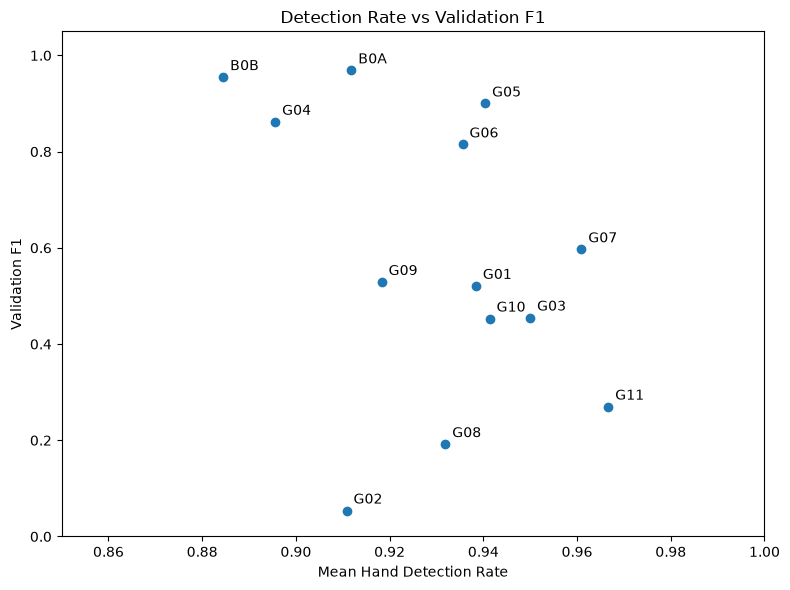

In [50]:
plt.figure(figsize=(8, 6))

plt.scatter(
    class_diagnostics["detection_rate"],
    class_diagnostics["f1"],
)

for _, row in class_diagnostics.iterrows():
    plt.annotate(
        row["class"],
        (row["detection_rate"], row["f1"]),
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.xlabel("Mean Hand Detection Rate")
plt.ylabel("Validation F1")
plt.title("Detection Rate vs Validation F1")
plt.xlim(0.85, 1.0)
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

## Key Findings
1. Under the current GRU architecture and training configuration, the three temporal preprocessing strategies produced similar validation accuracy, while their training times differed substantially.

## Experiment 2: Add explicit motion features

#### 63 position features -> 126 features (63 position and 63 motion)
* we add the motion features by calculating change in x. 
* Change = position x(t) - position x(t-1)

#### 1. Calculate motion

In [51]:
def add_motion_features(sequence):
    """
    Add frame-to-frame landmark movement to position features.

    Input:
        sequence: (T, 63)

    Output:
        combined: (T, 126)
    """
    motion = np.zeros_like(sequence) ## for the first sequence we take (0,0,0)

    motion[1:] = sequence[1:] - sequence[:-1]

    combined = np.concatenate(
        [sequence, motion],
        axis=1,
    )

    return combined

#### 1.1 Test motion features on one sequence

In [52]:
sample_sequence = train_sequences[0].landmarks

print("Original shape:", sample_sequence.shape)

sample_with_motion = add_motion_features(sample_sequence)

print("New shape:", sample_with_motion.shape)

Original shape: (38, 63)
New shape: (38, 126)


In [53]:
## first frame (expected: zeros)
print("First-frame motion:")
print(sample_with_motion[0, 63:])

## second frame
print("Second-frame motion:")
print(sample_with_motion[1, 63:])

First-frame motion:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Second-frame motion:
[ 0.00000000e+00  0.00000000e+00  0.00000000e+00 -6.96623325e-03
  1.62541866e-03  1.18620694e-03 -1.37428045e-02  7.97420740e-03
 -3.94623727e-04 -1.40157044e-02  9.10103321e-03 -7.16663897e-04
 -2.65052915e-03 -6.66862726e-03 -1.99694186e-04 -1.66078806e-02
  1.12497807e-02 -4.45629470e-04 -1.19708180e-02  1.78351998e-02
  5.09321690e-05 -5.66968322e-03  1.44997239e-02  2.07662582e-04
 -1.52844191e-03  4.88072634e-03  1.04315579e-03 -1.51061118e-02
  8.15671682e-03  1.40783004e-03 -1.32652521e-02  9.13912058e-03
  2.06325948e-03 -8.72427225e-03  1.53541565e-02  4.63985652e-03
 -5.48774004e-03  2.05713809e-02  8.64698738e-03 -1.19580328e-02
  4.98080254e-03  4.07871790e-03 -5.03939390e-03  7.61321187e-03
  8.08652490e-03  1.89995766e-03  3.13901901e-03  1

#### 1.2 Apply transformation to train and validation sequences

In [54]:
train_sequences_with_motion = [
    add_motion_features(sequence.landmarks)
    for sequence in train_sequences
]

validation_sequences_with_motion = [
    add_motion_features(sequence.landmarks)
    for sequence in validation_sequences
]

print("Training sequences:", len(train_sequences_with_motion))
print("Validation sequences:", len(validation_sequences_with_motion))

print(
    "Example training shape:",
    train_sequences_with_motion[0].shape,
)

print(
    "Example validation shape:",
    validation_sequences_with_motion[0].shape,
)

Training sequences: 2484
Validation sequences: 633
Example training shape: (38, 126)
Example validation shape: (123, 126)


#### Functions used by hybrid strategy

In [55]:
def resample_sequence(sequence, target_length):
    """
    Resample a temporal sequence to a fixed number of frames.

    Input:
        sequence: (T, F)
        target_length: desired number of frames

    Output:
        resampled sequence: (target_length, F)
    """
    original_length = sequence.shape[0]

    if original_length == target_length:
        return sequence.copy()

    original_positions = np.linspace(
        0,
        original_length - 1,
        num=original_length,
    )

    target_positions = np.linspace(
        0,
        original_length - 1,
        num=target_length,
    )

    resampled = np.empty(
        (target_length, sequence.shape[1]),
        dtype=np.float32,
    )

    for feature_index in range(sequence.shape[1]):
        resampled[:, feature_index] = np.interp(
            target_positions,
            original_positions,
            sequence[:, feature_index],
        )

    return resampled

In [56]:
SHORT_SEQUENCE_LIMIT = 192
LONG_SEQUENCE_LIMIT = 256


def prepare_sequence(sequence, strategy):
    """
    Apply a temporal preprocessing strategy to a sequence.
    """
    sequence_length = sequence.shape[0]

    if strategy == "fixed_192":
        return resample_sequence(
            sequence,
            SHORT_SEQUENCE_LIMIT,
        )

    if strategy == "fixed_256":
        return resample_sequence(
            sequence,
            LONG_SEQUENCE_LIMIT,
        )

    if strategy == "hybrid":
        if sequence_length < SHORT_SEQUENCE_LIMIT:
            target_length = sequence_length
        elif sequence_length <= LONG_SEQUENCE_LIMIT:
            target_length = SHORT_SEQUENCE_LIMIT
        else:
            target_length = LONG_SEQUENCE_LIMIT

        return resample_sequence(
            sequence,
            target_length,
        )

    raise ValueError(
        f"Unknown sequence strategy: {strategy}"
    )

In [57]:
train_motion_hybrid = [
    prepare_sequence(sequence, "hybrid")
    for sequence in train_sequences_with_motion
]

validation_motion_hybrid = [
    prepare_sequence(sequence, "hybrid")
    for sequence in validation_sequences_with_motion
]

print("Training sequences:", len(train_motion_hybrid))
print("Validation sequences:", len(validation_motion_hybrid))

print("Example training shape:", train_motion_hybrid[0].shape)
print("Example validation shape:", validation_motion_hybrid[0].shape)

Training sequences: 2484
Validation sequences: 633
Example training shape: (38, 126)
Example validation shape: (123, 126)


In [58]:
train_feature_sizes = {
    sequence.shape[1]
    for sequence in train_motion_hybrid
}

validation_feature_sizes = {
    sequence.shape[1]
    for sequence in validation_motion_hybrid
}

print("Training feature sizes:", train_feature_sizes)
print("Validation feature sizes:", validation_feature_sizes)

Training feature sizes: {126}
Validation feature sizes: {126}


#### 3. Build and implement the 126 input GRU

#### 3.1 Imports and configuration

In [59]:
import torch
import torch.nn as nn

INPUT_SIZE = 126
HIDDEN_SIZE = 128
NUM_LAYERS = 1
NUM_CLASSES = 13
DROPOUT = 0.0

#### 3.2 GRU Model

In [60]:
class GestureGRU(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size,
        num_layers,
        num_classes,
        dropout=0.0,
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size = input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.classifier = nn.Linear(
            hidden_size,num_classes
        )

    def forward(self,x,lengths):
        packed = nn.utils.rnn.pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )
        _,hidden = self.gru(packed)
        final_hidden = hidden[-1]
        return self.classifier(final_hidden)

In [61]:
model = GestureGRU(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT,
)

print(model)

GestureGRU(
  (gru): GRU(126, 128, batch_first=True)
  (classifier): Linear(in_features=128, out_features=13, bias=True)
)


In [62]:
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print("Total parameters:", total_parameters)

Total parameters: 99981


#### 3.3 Convert numpy sequences into PyTorch tensors

In [63]:
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence


class GestureDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = np.asarray(labels) - 2

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        sequence = torch.tensor(
            self.sequences[index],
            dtype=torch.float32,
        )

        label = torch.tensor(
            self.labels[index],
            dtype=torch.long,
        )

        return sequence, label

In [64]:
def collate_sequences(batch):
    sequences, labels = zip(*batch)

    padded_sequences = pad_sequence(
        sequences,
        batch_first=True,
        padding_value=0.0,
    )

    lengths = torch.tensor(
        [sequence.shape[0] for sequence in sequences],
        dtype=torch.long,
    )

    labels = torch.stack(labels)

    return padded_sequences, lengths, labels

In [65]:
## create the datasets
train_dataset = GestureDataset(
    train_motion_hybrid,
    [sequence.class_id for sequence in train_sequences],
)

validation_dataset = GestureDataset(
    validation_motion_hybrid,
    [sequence.class_id for sequence in validation_sequences],
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(validation_dataset))

Training samples: 2484
Validation samples: 633


#### 3.4 Dataloaders

In [66]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_sequences,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_sequences,
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))

Training batches: 78
Validation batches: 20


#### 3.5 Test on one batch

In [67]:
batch_sequences, batch_lengths, batch_labels = next(
    iter(train_loader)
)

print("Batch sequences:", batch_sequences.shape)
print("Batch lengths:", batch_lengths.shape)
print("Batch labels:", batch_labels.shape)

Batch sequences: torch.Size([32, 256, 126])
Batch lengths: torch.Size([32])
Batch labels: torch.Size([32])


## Colab Environment Configuration

In [1]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

2.11.0+cu128
True
Tesla T4


In [2]:
from pathlib import Path
import sys

print("Current working directory:")
print(Path.cwd())

print("\nPython executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Current working directory:
/content

Python executable:
/usr/bin/python3

Python version:
3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


In [3]:
from pathlib import Path

print("Notebook working directory:", Path.cwd())
print("Notebook file:", Path("03_model_analysis.ipynb").exists())

Notebook working directory: /content
Notebook file: False


In [4]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [6]:
from pathlib import Path

drive_root = Path("/content/drive/MyDrive")

matches = list(
    drive_root.rglob("train_sequences.pkl")
)

for path in matches:
    print(path)

In [7]:
matches = list(
    drive_root.rglob("validation_sequences.pkl")
)

for path in matches:
    print(path)

In [8]:
from pathlib import Path
import shutil

drive_landmark_dir = (
    Path("/content/drive/MyDrive")
    / "AirCommand"
    / "landmarks"
)

project_landmark_dir = (
    Path("/content/AirCommand")
    / "data"
    / "processed"
    / "landmarks"
)

project_landmark_dir.mkdir(
    parents=True,
    exist_ok=True,
)

for filename in [
    "train_sequences.pkl",
    "validation_sequences.pkl",
]:
    source = drive_landmark_dir / filename
    destination = project_landmark_dir / filename

    if not source.exists():
        raise FileNotFoundError(
            f"Could not find: {source}"
        )

    shutil.copy2(
        source,
        destination,
    )

    print(f"Copied: {filename}")

Copied: train_sequences.pkl
Copied: validation_sequences.pkl


## Key Findings
1. Model can get explicit information about direction through the explicit motion features